# Task 3: Jointly Trained Soft Mixture-of-Experts (SoftMoERestorationNetwork)

**Generative AI Restoration Studio — Milestone 3b**

This notebook implements:
1. **SoftMoERestorationNetwork**: 4 expert branches (Clean identity bypass + 3 specialist autoencoders) controlled by a temperature-scaled softmax gate network.
2. **Warm-Start Initialization**: Pretrained weights from Task 2 classifier and specialists.
3. **Two-Phase Training**: Phase 1 (Gate warm-up with frozen experts) -> Phase 2 (Joint end-to-end fine-tuning).
4. **4-Term Composite Loss**: $\mathcal{L}_{\text{total}} = 0.8 \mathcal{L}_{\text{recon}} + 0.2 \mathcal{L}_{\text{class}} + 0.1 \mathcal{L}_{\text{balance}} + 0.01 \mathcal{L}_{\text{entropy}}$ (fixed constants per spec).
5. **Optuna 15-Trial Study**: Hyperparameter tuning for $\tau$, $\eta_{\text{joint}}$, $\eta_{\text{warmup}}$, $\text{warmup\_epochs}$, and $\text{weight\_decay}$.
6. **4-Way Benchmark**: Comprehensive evaluation against Universal (Task 1), Oracle Hard, and Predicted Hard (Task 2) across 3,669 test images.
7. **Gating Analysis**: Weight distribution heatmaps and routing behavior analysis across corruptions.
8. **Self-Contained ONNX Export**: Opset 18 multi-output export with numerical parity verification.

In [4]:
# Step 1: Install Dependencies & Verify GPU
!pip install -q onnx onnxruntime onnxscript mlflow optuna matplotlib seaborn
import torch
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

PyTorch Version: 2.11.0+cu128
CUDA Available: True
GPU Device: Tesla T4
GPU Memory: 15.64 GB


In [5]:
# Step 2: Google Drive Mount, Repository Sync & Dependencies Installation
import os
import sys
import shutil
import time

# 1. Mount Google Drive
try:
    from google.colab import drive
    drive.mount("/content/drive")
    print("Google Drive mounted successfully at /content/drive")
except ImportError:
    print("Running outside Google Colab environment.")

PROJECT_DIR = "/content/drive/MyDrive/GenAI-A1"

# 2. Clone or update repository for code imports
REPO_URL = "https://github.com/UsmanBari/genai-restoration-studio.git"
REPO_DIR = "/content/genai-restoration-studio"

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL} {REPO_DIR}
else:
    %cd {REPO_DIR}
    !git pull origin main

%cd {REPO_DIR}
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

print(f"Active code directory: {os.getcwd()}")

# 3. Install required Colab dependencies
!pip install -q -r requirements-colab.txt
!pip install -q onnxscript mlflow optuna matplotlib seaborn
print("Dependencies installed successfully.")

# 4. Fast bulk copy of images to local Colab NVMe disk
DRIVE_IMAGES_DIR = os.path.join(PROJECT_DIR, "raw/OxfordPet/images_128x128")
if not os.path.exists(DRIVE_IMAGES_DIR):
    DRIVE_IMAGES_DIR = os.path.join(PROJECT_DIR, "data/raw/OxfordPet/images_128x128")

LOCAL_DATA_DIR = "/content/local_data/OxfordPet"
LOCAL_IMAGES_DIR = os.path.join(LOCAL_DATA_DIR, "images_128x128")
os.makedirs(LOCAL_IMAGES_DIR, exist_ok=True)

existing_local_count = len([f for f in os.listdir(LOCAL_IMAGES_DIR) if f.lower().endswith((".jpg", ".jpeg", ".png"))])

if existing_local_count >= 7349:
    print(f"⚡ Local NVMe cache already populated ({existing_local_count} images in {LOCAL_IMAGES_DIR}). Skipping copy.")
elif os.path.exists(DRIVE_IMAGES_DIR):
    print(f"🚀 Caching 7,349 images from Google Drive to local Colab NVMe disk: {LOCAL_IMAGES_DIR}...")
    !cp -r {DRIVE_IMAGES_DIR}/* {LOCAL_IMAGES_DIR}/
    cached_count = len([f for f in os.listdir(LOCAL_IMAGES_DIR) if f.lower().endswith((".jpg", ".jpeg", ".png"))])
    print(f"✅ Successfully cached {cached_count} images to local path: {LOCAL_IMAGES_DIR}")
else:
    print(f"Active images directory set to fallback: {DRIVE_IMAGES_DIR}")
    LOCAL_IMAGES_DIR = DRIVE_IMAGES_DIR

# 5. Configure MLflow SQLite tracking backend on Drive
import mlflow
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"
os.environ["MLFLOW_DISABLE_AGENT_HINT"] = "1"
MLFLOW_DB_PATH = os.path.join(PROJECT_DIR, "mlruns_task3.db")
os.makedirs(os.path.dirname(MLFLOW_DB_PATH), exist_ok=True)
mlflow.set_tracking_uri(f"sqlite:///{MLFLOW_DB_PATH}")
print(f"MLflow tracking URI configured: sqlite:///{MLFLOW_DB_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully at /content/drive
/content/genai-restoration-studio
From https://github.com/UsmanBari/genai-restoration-studio
 * branch            main       -> FETCH_HEAD
Already up to date.
/content/genai-restoration-studio
Active code directory: /content/genai-restoration-studio
Dependencies installed successfully.
⚡ Local NVMe cache already populated (7349 images in /content/local_data/OxfordPet/images_128x128). Skipping copy.
MLflow tracking URI configured: sqlite:////content/drive/MyDrive/GenAI-A1/mlruns_task3.db


In [6]:
import os
print(os.listdir('/content/drive/MyDrive/GenAI-A1'))

['raw', 'checkpoints', 'mlruns', 'manifests', 'exports', 'evaluation_task1', 'benchmarks', 'visualizations', 'mlruns_task2.db']


In [7]:
# Step 3: Setup Datasets & DataLoaders
import torch
from torch.utils.data import DataLoader
from data.oxford_pet import OxfordPetDataset, collate_oxford

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32
MANIFESTS_DIR = os.path.join(REPO_DIR, "configs/manifests")
if not os.path.exists(MANIFESTS_DIR):
    MANIFESTS_DIR = os.path.join(PROJECT_DIR, "configs/manifests")

train_dataset = OxfordPetDataset(
    manifest_path=MANIFESTS_DIR,
    images_dir=LOCAL_IMAGES_DIR,
    split="train"
)
val_dataset = OxfordPetDataset(
    manifest_path=MANIFESTS_DIR,
    images_dir=LOCAL_IMAGES_DIR,
    split="val"
)
test_dataset = OxfordPetDataset(
    manifest_path=MANIFESTS_DIR,
    images_dir=LOCAL_IMAGES_DIR,
    split="test"
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_oxford, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_oxford, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_oxford, num_workers=0, pin_memory=True)

print(f"Train samples: {len(train_dataset)} | Val samples: {len(val_dataset)} | Test samples: {len(test_dataset)}")

Train samples: 2944 | Val samples: 736 | Test samples: 3669


In [8]:
# Step 4: Define Paths to Warm-Start Weights from Task 2
WARMSTART_PATHS = {
    "classifier": os.path.join(PROJECT_DIR, "checkpoints/task2/best_classifier.pth"),
    "sp": os.path.join(PROJECT_DIR, "checkpoints/task2/best_specialist_salt_and_pepper.pth"),
    "blur": os.path.join(PROJECT_DIR, "checkpoints/task2/best_specialist_gaussian_blur.pth"),
    "occlusion": os.path.join(PROJECT_DIR, "checkpoints/task2/best_specialist_rectangular_occlusion.pth")
}

print("Checking warm-start checkpoints:")
for name, path in WARMSTART_PATHS.items():
    exists = os.path.exists(path)
    size_mb = os.path.getsize(path) / (1024*1024) if exists else 0
    status = f"[FOUND - {size_mb:.2f} MB]" if exists else "[WARNING: NOT FOUND]"
    print(f"  - {name:<12}: {status} {path}")

Checking warm-start checkpoints:
  - classifier  : [FOUND - 13.49 MB] /content/drive/MyDrive/GenAI-A1/checkpoints/task2/best_classifier.pth
  - sp          : [FOUND - 52.16 MB] /content/drive/MyDrive/GenAI-A1/checkpoints/task2/best_specialist_salt_and_pepper.pth
  - blur        : [FOUND - 52.16 MB] /content/drive/MyDrive/GenAI-A1/checkpoints/task2/best_specialist_gaussian_blur.pth
  - occlusion   : [FOUND - 52.16 MB] /content/drive/MyDrive/GenAI-A1/checkpoints/task2/best_specialist_rectangular_occlusion.pth


In [9]:
# Step 5: Optuna Hyperparameter Optimization Study (15 Trials)
import optuna
from training.optuna_moe import run_optuna_moe_study

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = run_optuna_moe_study(
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    warmstart_paths=WARMSTART_PATHS,
    n_trials=15,
    epochs_per_trial=4,
    study_name="task3_soft_moe_optimization"
)

best_params = study.best_params
print("\nSelected Optimal Hyperparameters:")
for k, v in best_params.items():
    print(f"  {k}: {v}")


[OPTUNA] Starting 15-trial study for Soft MoE (4 epochs/trial)...
[MoE Warmstart] Successfully loaded gate classifier (base_channels=32) from /content/drive/MyDrive/GenAI-A1/checkpoints/task2/best_classifier.pth
[MoE Warmstart] Successfully loaded specialist 'sp' (base_channels=64, bottleneck_dim=96) from /content/drive/MyDrive/GenAI-A1/checkpoints/task2/best_specialist_salt_and_pepper.pth
[MoE Warmstart] Successfully loaded specialist 'blur' (base_channels=64, bottleneck_dim=96) from /content/drive/MyDrive/GenAI-A1/checkpoints/task2/best_specialist_gaussian_blur.pth
[MoE Warmstart] Successfully loaded specialist 'occlusion' (base_channels=64, bottleneck_dim=96) from /content/drive/MyDrive/GenAI-A1/checkpoints/task2/best_specialist_rectangular_occlusion.pth
[MoE Warmstart] Successfully loaded gate classifier (base_channels=32) from /content/drive/MyDrive/GenAI-A1/checkpoints/task2/best_classifier.pth
[MoE Warmstart] Successfully loaded specialist 'sp' (base_channels=64, bottleneck_dim

In [10]:
# Step 6: Full 2-Phase Training of SoftMoERestorationNetwork
import mlflow
from models.moe import SoftMoERestorationNetwork
from training.trainer_moe import train_soft_moe

mlflow.set_experiment("Task3_Soft_Mixture_of_Experts")

# Instantiate model and warm-start weights
soft_moe_model = SoftMoERestorationNetwork(
    temperature=best_params.get("temperature", 1.0)
).to(device)

status = soft_moe_model.load_warmstart_weights(
    classifier_path=WARMSTART_PATHS["classifier"],
    sp_path=WARMSTART_PATHS["sp"],
    blur_path=WARMSTART_PATHS["blur"],
    occlusion_path=WARMSTART_PATHS["occlusion"],
    device=str(device)
)
print(f"Warm-start load status: {status}")
assert all(status.values()), f"CRITICAL: Warmstart failed! One or more weights did not load: {status}"

with mlflow.start_run(run_name="Soft_MoE_2Phase_Final"):
    mlflow.log_params(best_params)
    results = train_soft_moe(
        model=soft_moe_model,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        save_dir=os.path.join(PROJECT_DIR, "checkpoints/task3"),
        warmup_epochs=best_params.get("warmup_epochs", 2),
        joint_epochs=30,
        lr_warmup=best_params.get("lr_warmup", 5e-4),
        lr_joint=best_params.get("lr_joint", 1e-4),
        temperature=best_params.get("temperature", 1.0),
        lambda_recon=0.8,
        lambda_class=0.2,
        lambda_balance=0.1,
        lambda_entropy=0.01,
        alpha=0.90
    )
    mlflow.log_metric("best_val_psnr", results["best_val_psnr"])
    mlflow.log_metric("best_epoch", results["best_epoch"])

2026/09/27 14:10:43 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/27 14:10:43 INFO mlflow.store.db.utils: Updating database tables
2026/09/27 14:10:51 INFO mlflow.tracking.fluent: Experiment with name 'Task3_Soft_Mixture_of_Experts' does not exist. Creating a new experiment.


[MoE Warmstart] Successfully loaded gate classifier (base_channels=32) from /content/drive/MyDrive/GenAI-A1/checkpoints/task2/best_classifier.pth
[MoE Warmstart] Successfully loaded specialist 'sp' (base_channels=64, bottleneck_dim=96) from /content/drive/MyDrive/GenAI-A1/checkpoints/task2/best_specialist_salt_and_pepper.pth
[MoE Warmstart] Successfully loaded specialist 'blur' (base_channels=64, bottleneck_dim=96) from /content/drive/MyDrive/GenAI-A1/checkpoints/task2/best_specialist_gaussian_blur.pth
[MoE Warmstart] Successfully loaded specialist 'occlusion' (base_channels=64, bottleneck_dim=96) from /content/drive/MyDrive/GenAI-A1/checkpoints/task2/best_specialist_rectangular_occlusion.pth
Warm-start load status: {'gate': True, 'sp': True, 'blur': True, 'occlusion': True}
Starting Soft MoE 2-Phase Training
  Warm-Up Phase:       1 epochs (lr=2.45e-04, Experts Frozen)
  Joint Fine-Tuning:   30 epochs (lr=4.19e-04, End-to-End)
  Temperature tau:     0.50
  Loss Weights:        recon=0

In [11]:
# Step 7: 4-Way Comparative Benchmark (Universal vs Oracle Hard vs Pred Hard vs Soft MoE)
from models.autoencoders import UniversalAutoencoder
from models.classifiers import CorruptionClassifier
from models.hard_router import HardRoutingRestorationPipeline
from evaluation.benchmark_moe import run_4way_benchmark

# 1. Load Universal Baseline (Task 1)
universal_model = UniversalAutoencoder(base_channels=64, bottleneck_dim=96, dropout_rate=0.0).to(device)
candidate_u_paths = [
    os.path.join(PROJECT_DIR, "checkpoints/task1_universal_best.pth"),
    os.path.join(PROJECT_DIR, "checkpoints/best_universal.pth"),
    os.path.join(PROJECT_DIR, "checkpoints/task1/best_universal.pth"),
    "/content/drive/MyDrive/GenAI-A1/checkpoints/task1_universal_best.pth",
    "/content/drive/MyDrive/GenAI-A1/checkpoints/best_universal.pth",
    "checkpoints/task1_universal_best.pth"
]
loaded_u_path = next((p for p in candidate_u_paths if os.path.isfile(p)), None)
if loaded_u_path:
    ckpt = torch.load(loaded_u_path, map_location=device)
    universal_model.load_state_dict(ckpt.get("model_state_dict", ckpt))
    print(f"Loaded Task 1 Universal Autoencoder from {loaded_u_path}.")
else:
    print(f"Warning: Task 1 checkpoint not found in candidate paths.")

# 2. Load Task 2 Classifier and Specialists for Hard Router
classifier_model = CorruptionClassifier(base_channels=32, dropout_rate=0.2).to(device)
if os.path.exists(WARMSTART_PATHS["classifier"]):
    ckpt = torch.load(WARMSTART_PATHS["classifier"], map_location=device)
    classifier_model.load_state_dict(ckpt.get("model_state_dict", ckpt))
    print("Loaded Task 2 Corruption Classifier.")

specialist_models = {}
for c_name, path in [("salt_and_pepper", WARMSTART_PATHS["sp"]), ("gaussian_blur", WARMSTART_PATHS["blur"]), ("rectangular_occlusion", WARMSTART_PATHS["occlusion"])]:
    sp_net = UniversalAutoencoder(base_channels=64, bottleneck_dim=96, dropout_rate=0.0).to(device)
    if os.path.exists(path):
        ckpt = torch.load(path, map_location=device)
        sp_net.load_state_dict(ckpt.get("model_state_dict", ckpt))
        print(f"Loaded Task 2 specialist '{c_name}' from {path}.")
    else:
        raise FileNotFoundError(f"Specialist checkpoint for '{c_name}' not found at {path}")
    specialist_models[c_name] = sp_net

hard_router = HardRoutingRestorationPipeline(
    classifier=classifier_model,
    specialists=specialist_models,
    device=device
)

# 3. Load Trained Soft MoE Model
soft_moe_ckpt_path = os.path.join(PROJECT_DIR, "checkpoints/task3/best_soft_moe.pth")
if os.path.exists(soft_moe_ckpt_path):
    ckpt = torch.load(soft_moe_ckpt_path, map_location=device)
    soft_moe_model.load_state_dict(ckpt["model_state_dict"])
    print("Loaded trained Soft MoE model.")

benchmark_results = run_4way_benchmark(
    universal_model=universal_model,
    hard_router=hard_router,
    soft_moe=soft_moe_model,
    test_loader=test_loader,
    output_json_path=os.path.join(PROJECT_DIR, "configs/benchmarks/task3_moe_benchmark_results.json"),
    device=str(device)
)

Loaded Task 1 Universal Autoencoder from /content/drive/MyDrive/GenAI-A1/checkpoints/task1_universal_best.pth.
Loaded Task 2 Corruption Classifier.
Loaded Task 2 specialist 'salt_and_pepper' from /content/drive/MyDrive/GenAI-A1/checkpoints/task2/best_specialist_salt_and_pepper.pth.
Loaded Task 2 specialist 'gaussian_blur' from /content/drive/MyDrive/GenAI-A1/checkpoints/task2/best_specialist_gaussian_blur.pth.
Loaded Task 2 specialist 'rectangular_occlusion' from /content/drive/MyDrive/GenAI-A1/checkpoints/task2/best_specialist_rectangular_occlusion.pth.
Loaded trained Soft MoE model.
=== Running 4-Way Comparative Benchmark (Task 3 Soft MoE) ===
Evaluated 3669 test images across 4 systems in 108.61s (29.60 ms/image).

Category               | Universal (Task 1) | Oracle Hard    | Pred Hard (Task 2) | Soft MoE (Task 3)
--------------------------------------------------------------------------------------------
Clean                  |  29.20dB / 0.888 | 100.00dB / 1.000 | 100.00dB / 1.0

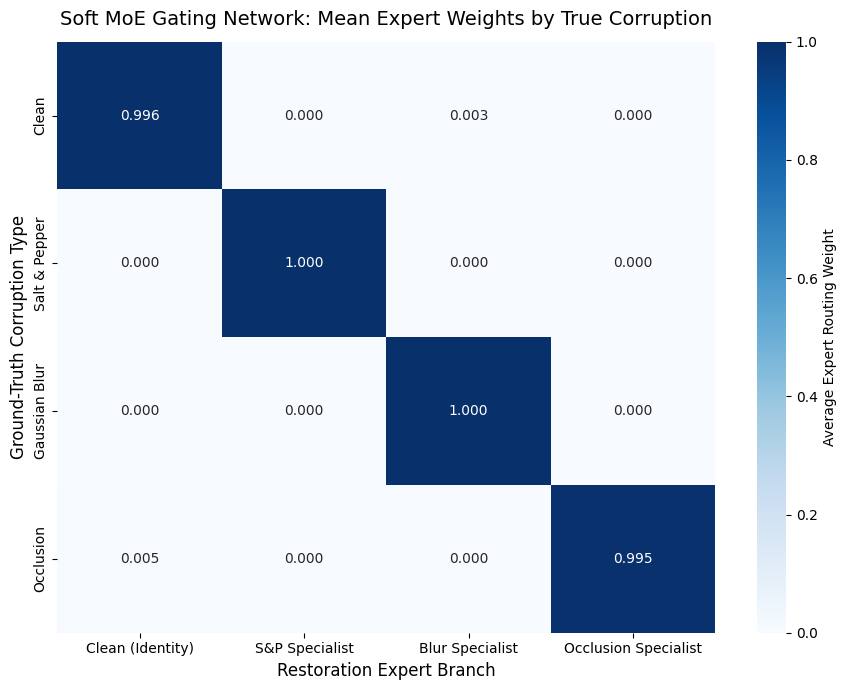

Saved routing heatmap to moe_gating_heatmap.png


In [12]:
# Step 8: Gating Network Weight Distribution & Routing Heatmap Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

gating_analysis = benchmark_results.get("gating_analysis", {})
weights_matrix = np.array(gating_analysis.get("mean_weights_matrix", np.eye(4)))
class_names = ["Clean", "Salt & Pepper", "Gaussian Blur", "Occlusion"]
expert_names = ["Clean (Identity)", "S&P Specialist", "Blur Specialist", "Occlusion Specialist"]

plt.figure(figsize=(9, 7))
sns.heatmap(
    weights_matrix,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    xticklabels=expert_names,
    yticklabels=class_names,
    cbar_kws={"label": "Average Expert Routing Weight"}
)
plt.title("Soft MoE Gating Network: Mean Expert Weights by True Corruption", fontsize=14, pad=12)
plt.xlabel("Restoration Expert Branch", fontsize=12)
plt.ylabel("Ground-Truth Corruption Type", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, "moe_gating_heatmap.png"), dpi=200)
plt.show()
print("Saved routing heatmap to moe_gating_heatmap.png")

In [13]:
# Step 9: Self-Contained ONNX Export & Parity Verification
from models.onnx_export import export_to_onnx, verify_onnx_numerical_equivalence

soft_moe_model.eval().cpu()
onnx_save_path = os.path.join(PROJECT_DIR, "models/task3_soft_moe.onnx")

export_to_onnx(
    model=soft_moe_model,
    onnx_output_path=onnx_save_path,
    input_shape=(1, 3, 128, 128),
    opset_version=18,
    input_names=["corrupted_image"],
    output_names=["restored_image", "routing_weights", "logits"]
)

verification = verify_onnx_numerical_equivalence(
    model=soft_moe_model,
    onnx_path=onnx_save_path,
    sample_batch=torch.rand(2, 3, 128, 128),
    atol=1e-3,
    rtol=1e-2
)
print(f"\nSoft MoE ONNX Parity Status: {verification.get('parity_status', verification.get('equivalent'))}")

/content/genai-restoration-studio/models/moe.py:157: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if return_all_experts:


[SUCCESS] ONNX model successfully verified and exported (56.58 MB, 138 weight initializers).

=== ONNX Numerical Parity Verification ===
  Outputs Verified:     3 output tensors
  PyTorch Primary Out:  (2, 3, 128, 128) | Range: [0.2308, 0.8054]
  ONNX Primary Out:     (2, 3, 128, 128) | Range: [0.2308, 0.8054]
  Max Absolute Diff:    1.668930e-06 (Tolerance atol=0.001)
  Mean Squared Diff:    2.591261e-13
  Parity Status:        PASS (Equivalence Confirmed)

Soft MoE ONNX Parity Status: True
